# Telco Customer Churn Analysis

## Objective
The goal of this project is to analyze customer behavior and identify key factors contributing to churn in a telecom dataset. Additionally, a machine learning model is developed to predict customers who are likely to churn, enabling proactive retention strategies.

## Dataset Overview

- Each row represents a customer.
- The dataset includes customer demographics, service usage, billing details, and contract information.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df=pd.read_csv("C:\\Users\\veere\\OneDrive\\Desktop\\Customer segmentation\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

  - **Churn** → Whether the customer has left the service or not. We have mapped Yes -> 1 and No -> 0

In [2]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## Exploratory Data Analysis

### Monthly charge vs churn 

Customers with higher monthly charges exhibit a greater likelihood of churn, suggesting that pricing plays a role in customer attrition, particularly among cost-sensitive users

<Figure size 1000x600 with 0 Axes>

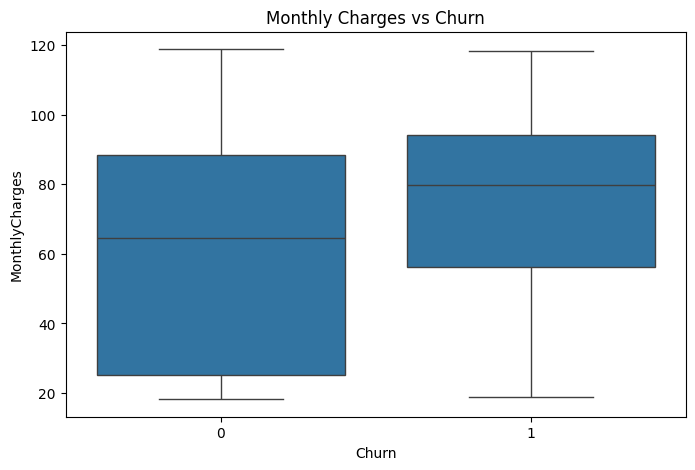

In [3]:
plt.figure(figsize=(10,6))
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


### Tenure vs Churn

Customers with lower tenure show significantly higher churn rates, indicating that early-stage customers are more likely to leave. This suggests that customers who remain beyond the initial months are more likely to continue using the service, highlighting the importance of early engagement and onboarding in reducing churn

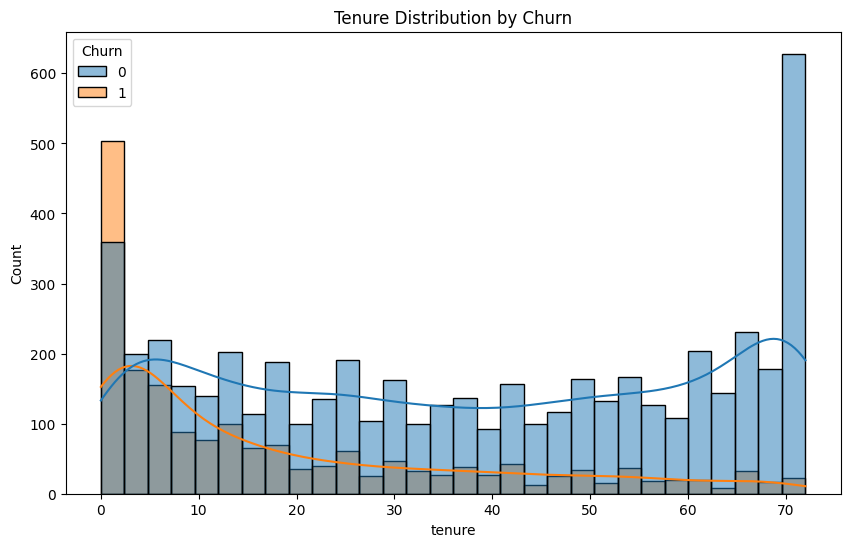

In [4]:

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()


### Contract type vs churn 

Customers on month-to-month contracts exhibit significantly higher churn rates compared to those on one-year or two-year contracts, indicating that lack of long-term commitment is a key factor influencing customer attrition.

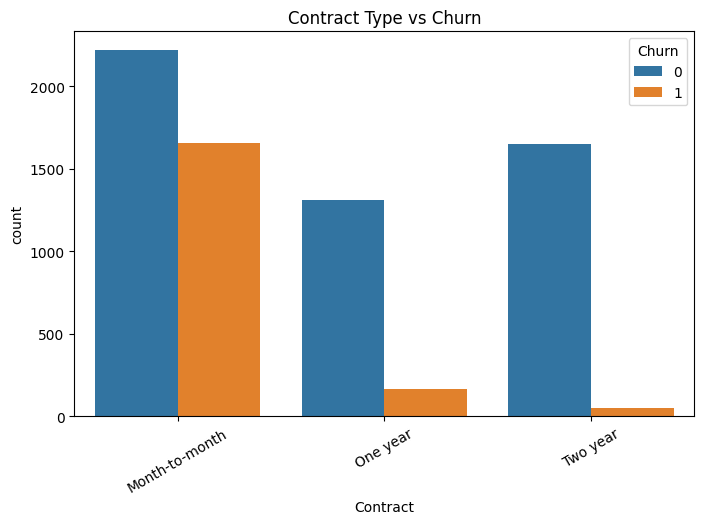

In [5]:

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.xticks(rotation=30)
plt.show()  


### Contract vs Monthly charges vs churn 

The impact of monthly charges on churn is strongly influenced by contract type. Customers with high monthly charges under month-to-month contracts exhibit the highest churn rates, whereas long-term contract users demonstrate greater retention even at higher price levels. This suggests that commitment significantly mitigates price sensitivity.

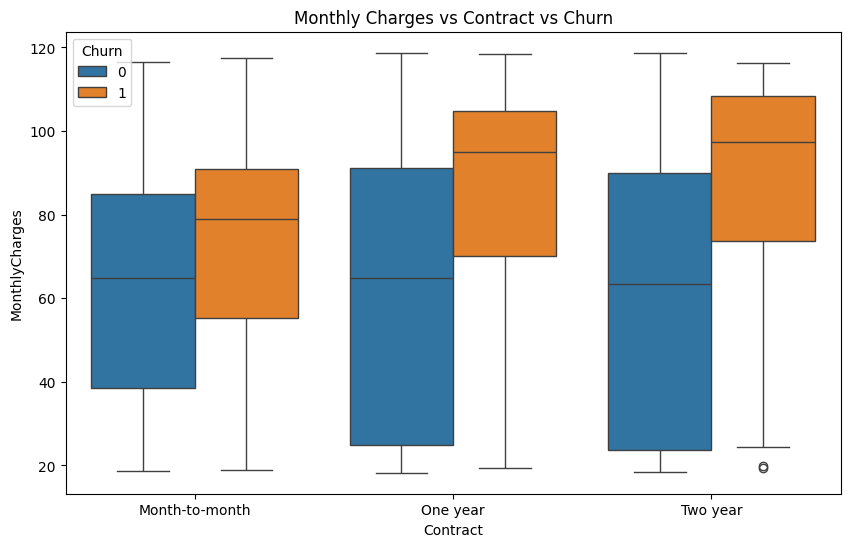

In [6]:

plt.figure(figsize=(10,6))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Monthly Charges vs Contract vs Churn')
plt.show()

## Data Preprocessing and Feature Engineering

- Computed churn rate across different contract types to quantify differences in customer attrition.
- Converted categorical variables such as contract type and service-related features into numerical format for model compatibility.
- Handled mixed data types in the `TotalCharges` column by converting it to numeric and treating invalid entries as missing values.
- Removed rows with missing values to ensure data consistency for modeling.

In [7]:
chr= df.groupby('Contract')['Churn'].mean()
print(chr*100, "%")

df['Contract']=df['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})
df['OnlineSecurity']=df['OnlineSecurity'].map({'No':0,'Yes':1,'No internet service':2})
df['OnlineBackup']=df['OnlineBackup'].map({'No':0,'Yes':1,'No internet service':2})
df['DeviceProtection']=df['DeviceProtection'].map({'No':0,'Yes':1,'No internet service':2})
df['TechSupport']=df['TechSupport'].map({'No':0,'Yes':1,'No internet service':2})
df['StreamingTV']=df['StreamingTV'].map({'No':0,'Yes':1,'No internet service':2})
df['StreamingMovies']=df['StreamingMovies'].map({'No':0,'Yes':1,'No internet service':2})  
df['PhoneService']=df['PhoneService'].map({'No':0,'Yes':1})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df=df.dropna()

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64 %


## Model Building and Training

- The dataset was divided into input features (X) and target variable (y), where the target represents customer churn.
- A train-test split of 80:20 was applied, where 80% of the data was used for training and 20% for testing to evaluate model performance on unseen data.
- Logistic Regression was used as the baseline classification model due to its simplicity and interpretability.
- The model was configured with `max_iter=1000` to ensure proper convergence during training.
- Class balancing was applied to handle imbalance in churn data.

In [13]:
x=df[['tenure','MonthlyCharges','Contract','TotalCharges','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PhoneService']]
y=df['Churn']

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('X train shape: ', X_train.shape)
print('Y train shape: ', y_train.shape)
print('X test shape: ', X_test.shape)
print('Y test shape: ', y_test.shape)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

X train shape:  (5625, 11)
Y train shape:  (5625,)
X test shape:  (1407, 11)
Y test shape:  (1407,)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Model Evaluation

- The trained Logistic Regression model was evaluated using standard classification metrics.
- Accuracy measures the overall correctness of the model.
- Precision indicates how many predicted churn cases were actually correct.
- Recall measures the model’s ability to correctly identify churned customers.
- F1 Score provides a balance between precision and recall.
- A confusion matrix was used to visualize correct and incorrect predictions.

### Results:
- The model achieved an accuracy of approximately 72%.
- Recall was significantly high (~79%), indicating that most churned customers were successfully identified.
- Precision was relatively lower (~48%), suggesting the presence of some false positives.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
y_pred = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7185501066098081
Precision: 0.4820261437908497
Recall: 0.7887700534759359
F1 Score: 0.5983772819472617
Confusion Matrix:
 [[716 317]
 [ 79 295]]


## Feature Importance Interpretation

The model coefficients indicate the impact of each feature on churn prediction.

- Positive coefficients (e.g., StreamingTV, StreamingMovies) are associated with a higher likelihood of churn.
- Negative coefficients (e.g., Contract, TechSupport, OnlineSecurity) indicate stronger customer retention.

Among all features, **contract type has the strongest negative influence**, highlighting that customers with long-term contracts are significantly less likely to churn due to increased commitment.

Additionally, value-added services such as **technical support and online security** are associated with lower churn, suggesting that customers who receive better service and support tend to remain more loyal

Overall, the results emphasize that both **customer commitment (contract type)** and **service quality (support and security features)** play a critical role in reducing churn.

In [15]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(importance)

             Feature  Coefficient
9    StreamingMovies     0.290178
8        StreamingTV     0.276502
1     MonthlyCharges     0.015478
6   DeviceProtection     0.008882
3       TotalCharges     0.000318
5       OnlineBackup    -0.045382
0             tenure    -0.058380
4     OnlineSecurity    -0.465576
7        TechSupport    -0.475025
10      PhoneService    -0.522762
2           Contract    -0.963023
